**Create Environment**  

In [1]:
from rocketpy import Environment, SolidMotor, Rocket, Flight, simulation
import datetime
import math
import matplotlib.pyplot as plt
import numpy as np


days_until_launch = 1
launch_date = datetime.date.today() + datetime.timedelta(days=days_until_launch)


#  For Building Environment
LATITUDE_MidlandTX = 31.83688    # [degrees]
LONGITUDE_MidlandTX = -102.010377    #  [degrees]
ELEVATION_MidlandTX = 855    # [m]
TIMEZONE_MidlandTX = "Etc/GMT-6"

#  For Building Environment
LATITUDE_PALMBAY_FL = 27.93226166667    # [degrees]
LONGITUDE_PALMBAY_FL = -80.7082766667    #  [degrees]
ELEVATION_PALMBAY_FL = 4    # [m]
TIMEZONE_PALMBAY_FL = "Etc/GMT-5"



#  For Building Airbrakes
ROCKETPY_EXAMPLE = "airbrakes_drag_coefficient_example_file.csv"
DRAG_COEFFICIENT_FILE = "airbrakes_drag_coefficient_from_Airbrakes.csv"
AIRBRAKES_DRAG_CSV_FILE = DRAG_COEFFICIENT_FILE



2 Ways of accomplishing the same thing  
Run either one of the next 2 cells 

The cell that uses  -  type="Forecast", file="GFS"  -  does not work any longer

Use  -  type="wyoming_sounding"  -

Fetching elevation from open-elevation.com for lat=27.93226166667, lon=-80.7082766667...
Elevation received: 7.0 m

Gravity Details

Acceleration of gravity at surface level:    9.7916 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5493 m/s²


Launch Site Details

Launch Site Latitude: 27.93226°
Launch Site Longitude: -80.70828°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: -62127.90 W    3102843.72 N
Launch Site UTM zone: 17R
Launch Site Surface Elevation: 7.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 1012.43 hPa
Surface Temperature: 288.10 K
Surface Air Density: 1.224 kg/m³
Surface Speed of Sound: 340.27 m/s


Earth Model Details

Earth Radius at Launch site: 6373.48 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospher

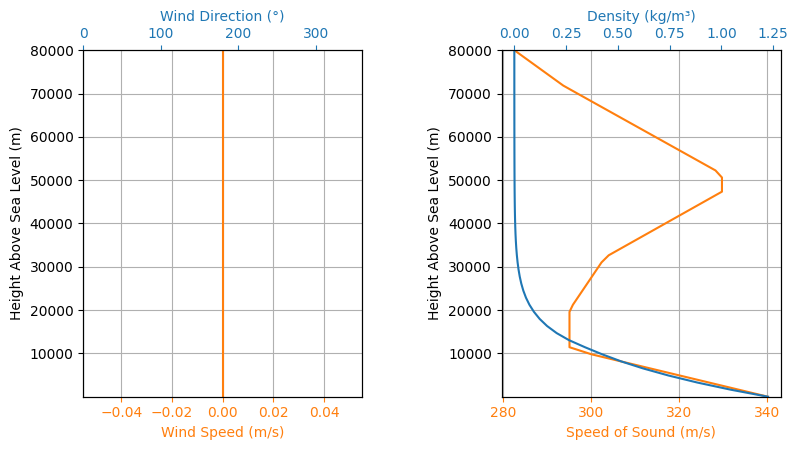

In [2]:
# Run either this cell or the previous cell
# These 2 cells accomplish the same thing in different ways
# This cell type is set to "Raw"

# GRAVITY_MidlandTX = 9.79207    # [ms^-2]

wyoming_sounding_URL = "https://weather.uwyo.edu/cgi-bin/sounding?region=naconf&TYPE=TEXT%3ALIST&YEAR=2025&MONTH=11&FROM=2712&TO=2712&STNM=72265"


env = Environment(
    latitude=LATITUDE_MidlandTX, 
    longitude=-LONGITUDE_MidlandTX,
    elevation=ELEVATION_MidlandTX,
    timezone=TIMEZONE_MidlandTX)

env = Environment(
    latitude=LATITUDE_PALMBAY_FL,
    longitude=LONGITUDE_PALMBAY_FL,
    elevation=ELEVATION_PALMBAY_FL,
    timezone=TIMEZONE_PALMBAY_FL)

env.set_elevation('Open-Elevation')
env.info()

env.set_date((launch_date.year, launch_date.month, launch_date.day, 12))  # Hour given in UTC time
env.set_atmospheric_model(type="wyoming_sounding",
                          file=wyoming_sounding_URL)



**BUILDING THE MOTOR**

In [3]:
M1939W = SolidMotor(
    thrust_source="AeroTech_M1939W.eng",
    dry_mass=3.33,  # kg
    dry_inertia=(0.148, 0.148, 0.00392),
    nozzle_radius=0.009325,  # m
    grain_number=4,
    grain_density=1709,  # kg/m3
    grain_outer_radius=0.0427355,  # m
    grain_initial_inner_radius=0.0142875,  # m
    grain_initial_height=0.1524,  # m
    grain_separation=0.01,  # m
    grains_center_of_mass_position=0.366,  # m
    center_of_dry_mass_position=0.366,  # m
    nozzle_position=0,
    burn_time=6.23,  # s
    coordinate_system_orientation="nozzle_to_combustion_chamber",
    )

**BUILDING THE ROCKET**

In [4]:
I = (4.656,4.656,0.088)  # kg*m2

rocket = Rocket(
    radius=(0.152)/2 + 0.00216, # m                       # Updated 18 March 2026
    mass=25.033,  # kg                                    # Updated 18 March 2026
    inertia= I, #(4.656,4.656,0.088), kg*m2
    power_off_drag="Cd_vs_Mach_openrocket_clean.csv",
    power_on_drag="Cd_vs_Mach_openrocket_clean.csv",
    center_of_mass_without_motor=(254+1.58),  # m          # Updated 18 March 2026
    coordinate_system_orientation="nose_to_tail",
    )

rocket.add_motor(M1939W,position=2.9)

**ADDING NOSE CONE**

In [5]:
# Updated 10 March 2026
# Updated from OpenRocket FIle:  IREC 2026 - PR2.okr

nose_cone=rocket.add_nose(
    length=0.762,  #  [m]
    kind="lvhaack",
    position=0.0
    )

**ADDING THE FINS**

Updated 10 March 2026

Updated from OpenRocket FIle:  IREC 2026 - PR2.okr

In [6]:
# Updated 10 March 2026
# Updated from OpenRocket FIle:  IREC 2026 - PR2.okr

fin_set=rocket.add_trapezoidal_fins(
    n=4,  # number of fins
    root_chord=0.305,    # [m]
    tip_chord=0.0406,    # [m]
    span=0.178,    # [m]       # NOT UPDATED
    position=2.49,             # NOT UPDATED
    cant_angle=0,    # [deg]
    sweep_length=.240,    # [m]
#    sweep_angle=52.7,    # [deg]
    )

**ADDING PARCHUTES**

To Do:
    Need to verify Drag Coefficient Calculation

Updated 10 March 2026

Updated from OpenRocket FIle:  IREC 2026 - PR2.okr

In [7]:
# Updated 10 March 2026
# Updated from OpenRocket FIle:  IREC 2026 - PR2.okr

main = rocket.add_parachute(
    name="main",
    #cd_s=9.77,  #  "Drag coefficient times reference area for parachute"
    #  Unsure of what is "reference area for parachute"
    cd_s=10.28708,  #  "Drag coefficient times reference area for parachute"  C_D = 2.2  |  Diameter = 2.44 m
    trigger=304.8,      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    )

drogue = rocket.add_parachute(
    name="drogue",
    #cd_s=0.293,  #  "Drag coefficient times reference area for parachute"
    #  Unsure of what is "reference area for parachute"
    cd_s=.45298,  #  "Drag coefficient times reference area for parachute"  C_D = 1.55  |  Diameter = .61 m
    trigger="apogee",  # ejection at apogee
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    )

**ADDING AIRBRAKES**

https://docs.rocketpy.org/en/latest/user/airbrakes.html
https://docs.rocketpy.org/en/latest/reference/classes/aero_surfaces/AirBrakes.html

function copied from:  https://docs.rocketpy.org/en/latest/user/airbrakes.html

    NEED TO FIND/CREATE  "air_brakes_cd.csv"

air_brakes = rocket.add_air_brakes(
    drag_coefficient_curve="air_brakes_cd.csv",


ROCKETPY_EXAMPLE = "airbrakes_drag_coefficient_example_file.csv"

AIRBRAKES_DRAG_CSV_FILE = ROCKETPY_EXAMPLE

In [8]:
# https://docs.rocketpy.org/en/latest/user/airbrakes.html
# https://docs.rocketpy.org/en/latest/reference/classes/aero_surfaces/AirBrakes.html

# function copied from:  https://docs.rocketpy.org/en/latest/user/airbrakes.html

#    NEED TO FIND/CREATE  "air_brakes_cd.csv"

#air_brakes = rocket.add_air_brakes(
#    drag_coefficient_curve="air_brakes_cd.csv",


# ROCKETPY_EXAMPLE = "airbrakes_drag_coefficient_example_file.csv"
# AIRBRAKES_DRAG_CSV_FILE = ROCKETPY_EXAMPLE



def controller_function(
    time, sampling_rate, state, state_history, observed_variables, air_brakes
):
    # state = [x, y, z, vx, vy, vz, e0, e1, e2, e3, wx, wy, wz]
    altitude_ASL = state[2]
    altitude_AGL = altitude_ASL - env.elevation
    vx, vy, vz = state[3], state[4], state[5]

    # Get winds in x and y directions
    wind_x, wind_y = env.wind_velocity_x(altitude_ASL), env.wind_velocity_y(altitude_ASL)

    # Calculate Mach number
    free_stream_speed = (
        (wind_x - vx) ** 2 + (wind_y - vy) ** 2 + (vz) ** 2
    ) ** 0.5
    mach_number = free_stream_speed / env.speed_of_sound(altitude_ASL)

    # Get previous state from state_history
    previous_state = state_history[-1]
    previous_vz = previous_state[5]

    # If we wanted to we could get the returned values from observed_variables:
    # returned_time, deployment_level, drag_coefficient = observed_variables[-1]

    # Check if the rocket has reached burnout
    if time < M1939W.burn_out_time:
        return None

    # If below 1500 meters above ground level, air_brakes are not deployed
    #if altitude_AGL < 1500:
    if altitude_AGL < 1524:  # If below 5,000 feet above ground level, air_brakes are not deployed
        air_brakes.deployment_level = 0

    # Else calculate the deployment level
    else:
        # Controller logic
        new_deployment_level = (
            air_brakes.deployment_level + 0.1 * vz + 0.01 * previous_vz**2
        )


        # Function to predict the rocket's apogee
        def prediction(time, altitude, velocity):
            dt = 0.1
            while velocity > 0:
                def f(t, a, v):
                    accel = -9.8
                    # accel = drag / mass - 9.8
                    return np.array([v, accel])
                
                k1 = f(time, altitude, velocity)
                k2 = f(time + dt/2, altitude + k1[0] * dt/2, velocity + k1[1] * dt/2)
                k3 = f(time + dt/2, altitude + k2[0] * dt/2, velocity + k2[1] * dt/2)
                k4 = f(time + dt, altitude + k3[0] * dt, velocity + k3[1] * dt)
        
                altitude += (dt/6) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
                velocity += (dt/6) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
                time += dt
            return altitude
        
        prediction(time, state[3], state[6])

        # Limiting the speed of the air_brakes to 0.2 per second
        # Since this function is called every 1/sampling_rate seconds
        # the max change in deployment level per call is 0.2/sampling_rate
        max_change = 0.2 / sampling_rate
        lower_bound = air_brakes.deployment_level - max_change
        upper_bound = air_brakes.deployment_level + max_change
        new_deployment_level = min(max(new_deployment_level, lower_bound), upper_bound)

        air_brakes.deployment_level = new_deployment_level

    # Return variables of interest to be saved in the observed_variables list
    return (
        time,
        air_brakes.deployment_level,
        air_brakes.drag_coefficient(air_brakes.deployment_level, mach_number),
    )



air_brakes = rocket.add_air_brakes(
    drag_coefficient_curve=AIRBRAKES_DRAG_CSV_FILE,  # File location 
    controller_function=controller_function,
    sampling_rate=10,
    reference_area=None,
    clamp=True,
    initial_observed_variables=[0, 0, 0],
    override_rocket_drag=False,
    name="Air Brakes",
)

print(vars(air_brakes))
print("\n\n")
print(vars(rocket))
#air_brakes.all_info()



{'reference_area': 0.019359279329583704, 'reference_length': None, 'name': 'Air Brakes', 'cpx': 0, 'cpy': 0, 'cpz': 0, 'drag_coefficient_curve': 'airbrakes_drag_coefficient_from_Airbrakes.csv', 'drag_coefficient': 'Function from R2 to R1 : (Deployment Level, Mach) → (Drag Coefficient)', 'clamp': True, 'override_rocket_drag': False, 'initial_deployment_level': 0, '_deployment_level': 0, 'prints': <rocketpy.prints.aero_surface_prints._AirBrakesPrints object at 0x0000024CD54CFAA0>, 'plots': <rocketpy.plots.aero_surface_plots._AirBrakesPlots object at 0x0000024CD5493170>}



{'coordinate_system_orientation': 'nose_to_tail', '_csys': -1, 'mass': 18.3, 'I_11_without_motor': 4.656, 'I_22_without_motor': 4.656, 'I_33_without_motor': 0.088, 'I_12_without_motor': 0, 'I_13_without_motor': 0, 'I_23_without_motor': 0, 'center_of_mass_without_motor': 1.65, 'radius': 0.0785, 'area': 0.019359279329583704, 'cm_eccentricity_x': 0, 'cm_eccentricity_y': 0, 'cp_eccentricity_x': 0, 'cp_eccentricity_y': 0, '

Debugging:

In [9]:
print("nothing")

nothing


**CREATING TEST LAUNCH**

In [10]:
test_flight = Flight(
    rocket=rocket,
    environment=env,
    rail_length=5.18,
    inclination=83,
    heading=0,
    time_overshoot=False,  # Required for controllers/sensors
    terminate_on_apogee=False,
    )

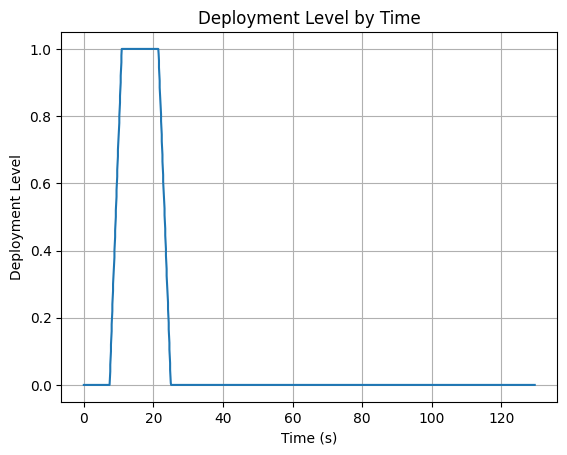

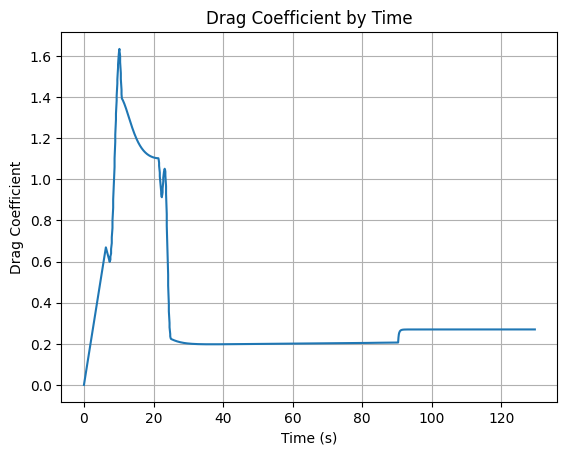


Burn out State

Burn out time: 6.230 s
Altitude at burn out: 2066.010 m (ASL) | 1194.010 m (AGL)
Rocket speed at burn out: 292.970 m/s
Freestream velocity at burn out: 293.007 m/s
Mach Number at burn out: 0.871
Kinetic energy at burn out: 9.283e+05 J

Apogee State

Apogee Time: 21.362 s
Apogee Altitude: 3678.890 m (ASL) | 2806.890 m (AGL)
Apogee Freestream Speed: 9.454 m/s
Apogee X position: 225.238 m
Apogee Y position: 163.266 m
Apogee latitude: 27.9337294°
Apogee longitude: -80.7059848°


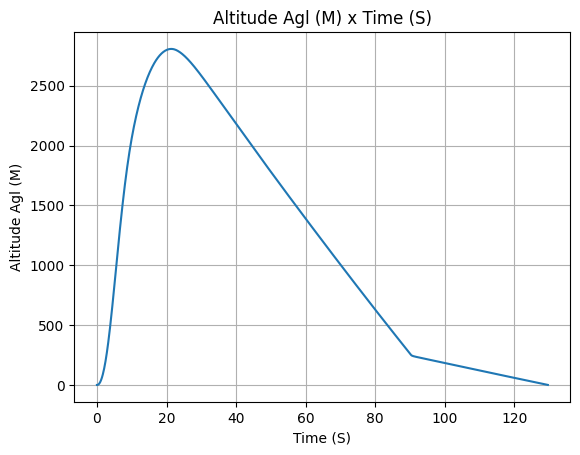

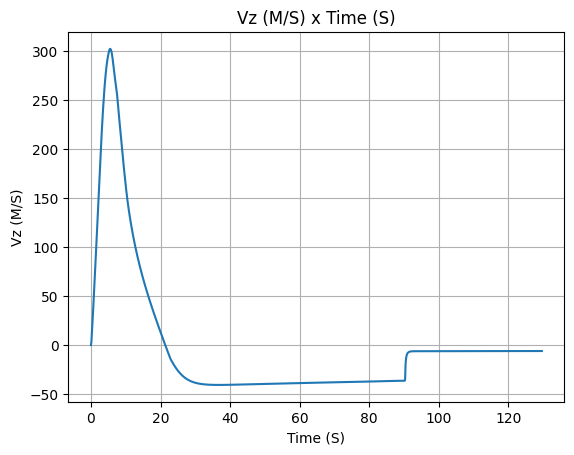

In [11]:
import matplotlib.pyplot as plt

time_list, deployment_level_list, drag_coefficient_list = [], [], []

obs_vars = test_flight.get_controller_observed_variables()

for time, deployment_level, drag_coefficient in obs_vars:
    time_list.append(time)
    deployment_level_list.append(deployment_level)
    drag_coefficient_list.append(drag_coefficient)

# Plot deployment level by time
plt.plot(time_list, deployment_level_list)
plt.xlabel("Time (s)")
plt.ylabel("Deployment Level")
plt.title("Deployment Level by Time")
plt.grid()
plt.show()

# Plot drag coefficient by time
plt.plot(time_list, drag_coefficient_list)
plt.xlabel("Time (s)")
plt.ylabel("Drag Coefficient")
plt.title("Drag Coefficient by Time")
plt.grid()
plt.show()

test_flight.prints.burn_out_conditions()
test_flight.prints.apogee_conditions()
test_flight.altitude()
test_flight.vz()

**CALLING ON SIMULATION FUNCTIONS**

In [ ]:
#rocket.all_info()
#rocket.plots.static_margin()

rocket.draw()
print("Trajectory Data")
test_flight.plots.trajectory_3d()
print("Kinematics Data")
test_flight.plots.linear_kinematics_data()
print("Energy Data")
#test_flight.plots.energy_data()

test_flight.info()

**Prepare for Monte Carlo Simulations**

In [ ]:
from rocketpy import simulation, MonteCarlo
from rocketpy.stochastic import (
    StochasticEnvironment,
    StochasticFlight,
    StochasticNoseCone,
    StochasticParachute,
    #StochasticRailButtons,
    StochasticRocket,
    StochasticSolidMotor,
    #StochasticTail,
    StochasticTrapezoidalFins,
    )

**Create "Stochastic" Version of Everything**

In [ ]:
stochastic_env = StochasticEnvironment(env)
stochastic_env.visualize_attributes()

In [ ]:
stochastic_env = StochasticEnvironment(env)
stochastic_env.visualize_attributes()

stochastic_rocket = StochasticRocket(rocket)
stochastic_rocket.visualize_attributes()

stochastic_motor = StochasticSolidMotor(
    solid_motor=M1939W,
    burn_start_time=(0, 0.1, "binomial"),
    grains_center_of_mass_position=0.001,
    grain_density=10,
    grain_separation=1 / 1000,
    grain_initial_height=1 / 1000,
    grain_initial_inner_radius=0.375 / 1000,
    grain_outer_radius=0.375 / 1000,
    total_impulse=(6500, 100),
    throat_radius=0.5 / 1000,
    nozzle_radius=0.5 / 1000,
    nozzle_position=0.001,
    )
stochastic_motor.visualize_attributes()

stochastic_main_parachute = StochasticParachute(
    parachute=main,
    cd_s=0.1,
    lag=0.1,
    )
stochastic_main_parachute.visualize_attributes()

stochastic_drogue_parachute = StochasticParachute(
    parachute=drogue,
    cd_s=0.07,
    lag=0.2,
    )
stochastic_drogue_parachute.visualize_attributes()

stochastic_fins = StochasticTrapezoidalFins(
    trapezoidal_fins=fin_set,
    root_chord=0.0005,
    tip_chord=0.0005,
    span=0.0005,
    )
stochastic_fins.visualize_attributes()

stochastic_nose_cone = StochasticNoseCone(
    nosecone=nose_cone,
    length=0.001,
    )
stochastic_nose_cone.visualize_attributes()

stochastic_rocket.add_motor(stochastic_motor, position=0.001)
stochastic_rocket.add_nose(stochastic_nose_cone, position=(1.134, 0.001))
stochastic_rocket.add_trapezoidal_fins(stochastic_fins, position=(0.001, "normal"))
stochastic_rocket.add_parachute(stochastic_main_parachute)
stochastic_rocket.add_parachute(stochastic_drogue_parachute)

stochastic_flight = StochasticFlight(
    flight=test_flight,
    inclination=(83, 1),  # mean= 83, std=1
    heading=(0, 2),  # mean= 0, std=2
    )
#stochastic_flight.visualize_attributes()


**Create Monte Carlo Simulation**

In [ ]:
#rocket.all_info()
#rocket.plots.static_margin()
#rocket.draw()
print("Trajectory Data")
#stochastic_flight.plots.trajectory_3d()
print("Kinematics Data")
#stochastic_flight.plots.linear_kinematics_data()
print("Energy Data")
#stochastic_flight.plots.energy_data()
#stochastic_flight.info()

In [ ]:

test_dispersion = MonteCarlo(
    filename="monte_carlo_analysis_outputs",
    environment=stochastic_env,
    rocket=stochastic_rocket,
    flight=stochastic_flight,
    )

test_dispersion.simulate(
    number_of_simulations=10,
    append=False,
    include_function_data=False,
    #parallel=True,
    #n_workers=4,
    )

test_dispersion.prints.all()
test_dispersion.plots.all()

**Export Google Earth KML file**

In [ ]:
test_dispersion.export_ellipses_to_kml(
    filename="monte_carlo_output.kml",
    origin_lat=env.latitude,
    origin_lon=env.longitude,
    type="impact",
    )